# Импорт библиотек

In [1]:
import copy
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

# Воспроизводимость

In [2]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Используемое устройство: {DEVICE}")

Используемое устройство: cpu


# Параметры

In [3]:
BATCH_SIZE = 128
EPOCHS = 30
PATIENCE = 5
VAL_SIZE = 5000
NUM_WORKERS = 2

In [4]:
CLASS_NAMES = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

# Преобразования нормализация для CIFAR-10

In [5]:
CIFAR10_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR10_STD = (0.2023, 0.1994, 0.2010)

In [6]:
train_transform_no_aug = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD)
])

In [7]:
train_transform_aug = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.RandomResizedCrop(size=32, scale=(0.85, 1.0)),
    transforms.ToTensor(),
    transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD)
])

In [8]:
test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD)
])

In [9]:
full_train_no_aug = datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=train_transform_no_aug
)

100.0%
/Users/lunis/PycharmProjects/machine_learning/.venv/lib/python3.11/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


In [10]:
full_train_aug = datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=train_transform_aug
)

In [11]:
full_train_for_val = datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=test_transform
)

In [12]:
test_dataset = datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=test_transform
)

In [13]:
train_size = len(full_train_no_aug) - VAL_SIZE
val_size = VAL_SIZE

In [14]:
indices = torch.randperm(len(full_train_no_aug), generator=torch.Generator().manual_seed(SEED)).tolist()
train_indices = indices[:train_size]
val_indices = indices[train_size:]

In [15]:
train_dataset_no_aug = torch.utils.data.Subset(full_train_no_aug, train_indices)
train_dataset_aug = torch.utils.data.Subset(full_train_aug, train_indices)
val_dataset = torch.utils.data.Subset(full_train_for_val, val_indices)

In [16]:
train_loader_no_aug = DataLoader(
    train_dataset_no_aug, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS
)
train_loader_aug = DataLoader(
    train_dataset_aug, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS
)
test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS
)

In [17]:
print(f"Train size: {train_size}")
print(f"Val size:   {val_size}")
print(f"Test size:  {len(test_dataset)}")

Train size: 45000
Val size:   5000
Test size:  10000


# Денормализация для отображения картинок

In [18]:
def denormalize(img, mean=CIFAR10_MEAN, std=CIFAR10_STD):
    img = img.clone().cpu()
    for c in range(3):
        img[c] = img[c] * std[c] + mean[c]
    return torch.clamp(img, 0, 1)

In [19]:
def show_samples(loader, class_names, n=8, title="Примеры изображений"):
    images, labels = next(iter(loader))
    plt.figure(figsize=(16, 4))
    for i in range(n):
        plt.subplot(1, n, i + 1)
        img = denormalize(images[i]).permute(1, 2, 0).numpy()
        plt.imshow(img)
        plt.title(class_names[labels[i].item()])
        plt.axis("off")
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

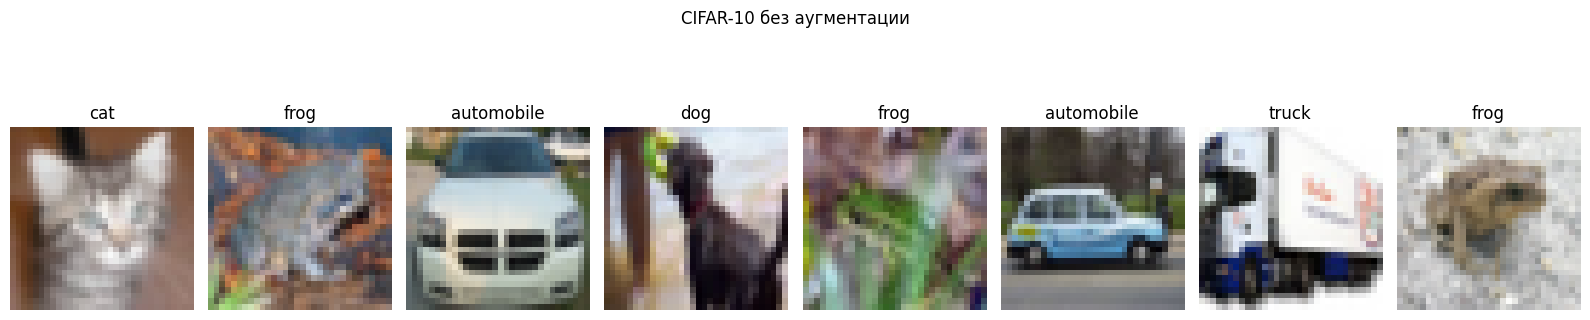

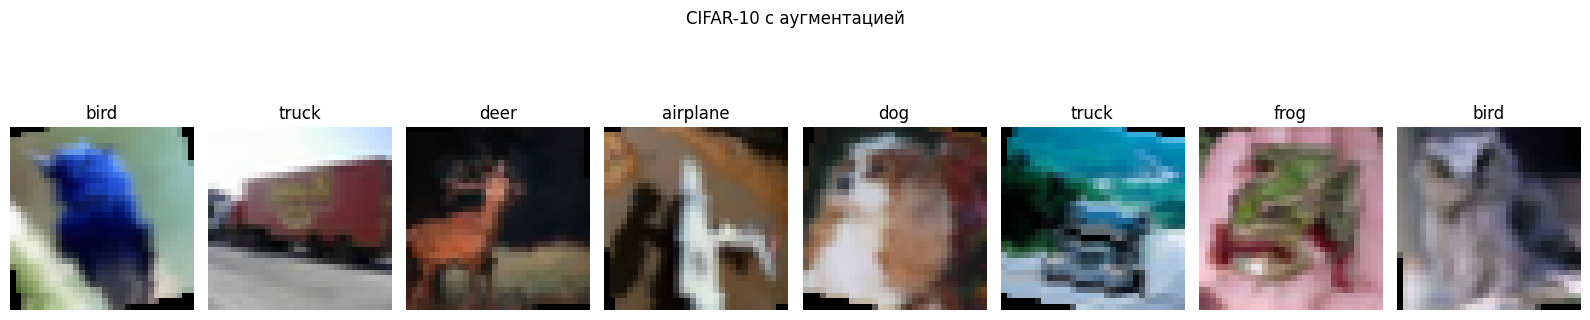

In [20]:
show_samples(train_loader_no_aug, CLASS_NAMES, title="CIFAR-10 без аугментации")
show_samples(train_loader_aug, CLASS_NAMES, title="CIFAR-10 с аугментацией")

# Архитектура CNN

In [21]:
class CNN_Small(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),  # 32 -> 16

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),  # 16 -> 8
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 8 * 8, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [22]:
class CNN_Medium(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),

            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),  # 32 -> 16
            nn.Dropout(0.25),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),  # 16 -> 8
            nn.Dropout(0.25),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 8 * 8, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [23]:
class CNN_Deep(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),

            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),   # 32 -> 16
            nn.Dropout(0.2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),   # 16 -> 8
            nn.Dropout(0.3),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),

            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),   # 8 -> 4
            nn.Dropout(0.4),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [24]:
class EarlyStopping:
    def __init__(self, patience=5, min_delta=0.0, mode="max"):
        self.patience = patience
        self.min_delta = min_delta
        self.mode = mode
        self.best_score = None
        self.counter = 0
        self.should_stop = False
        self.best_weights = None

    def step(self, score, model):
        if self.best_score is None:
            self.best_score = score
            self.best_weights = copy.deepcopy(model.state_dict())
            return

        improvement = (
            score > self.best_score + self.min_delta
            if self.mode == "max"
            else score < self.best_score - self.min_delta
        )

        if improvement:
            self.best_score = score
            self.counter = 0
            self.best_weights = copy.deepcopy(model.state_dict())
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.should_stop = True

    def restore_best_weights(self, model):
        if self.best_weights is not None:
            model.load_state_dict(self.best_weights)

In [25]:
def evaluate_model(model, dataloader, criterion):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    all_preds = []
    all_labels = []
    all_images = []

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(DEVICE)
            labels = labels.to(DEVICE)

            outputs = model(images)
            loss = criterion(outputs, labels)

            preds = torch.argmax(outputs, dim=1)

            total_loss += loss.item() * images.size(0)
            total_correct += (preds == labels).sum().item()
            total_samples += labels.size(0)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_images.extend(images.cpu())

    avg_loss = total_loss / total_samples
    avg_acc = total_correct / total_samples

    return avg_loss, avg_acc, np.array(all_labels), np.array(all_preds), all_images

# Обучение

In [26]:
def train_model(model, train_loader, val_loader, criterion, optimizer,
                epochs=30, patience=5, model_name="model"):
    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": [],
    }

    early_stopping = EarlyStopping(patience=patience, min_delta=1e-4, mode="max")

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        running_correct = 0
        running_total = 0

        for images, labels in train_loader:
            images = images.to(DEVICE)
            labels = labels.to(DEVICE)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            preds = torch.argmax(outputs, dim=1)
            running_loss += loss.item() * images.size(0)
            running_correct += (preds == labels).sum().item()
            running_total += labels.size(0)

        train_loss = running_loss / running_total
        train_acc = running_correct / running_total

        val_loss, val_acc, _, _, _ = evaluate_model(model, val_loader, criterion)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        print(
            f"{model_name} | Epoch {epoch+1:02d}/{epochs} | "
            f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
            f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}"
        )

        early_stopping.step(val_acc, model)
        if early_stopping.should_stop:
            print(f"Early stopping сработал для {model_name} на эпохе {epoch+1}")
            break

    early_stopping.restore_best_weights(model)
    return model, history, early_stopping.best_score

In [27]:
experiments = {
    "CNN_Small_no_aug": {
        "model_fn": CNN_Small,
        "train_loader": train_loader_no_aug,
        "optimizer_fn": lambda params: optim.Adam(params, lr=0.001),
    },
    "CNN_Small_aug": {
        "model_fn": CNN_Small,
        "train_loader": train_loader_aug,
        "optimizer_fn": lambda params: optim.Adam(params, lr=0.001),
    },
    "CNN_Medium_no_aug": {
        "model_fn": CNN_Medium,
        "train_loader": train_loader_no_aug,
        "optimizer_fn": lambda params: optim.Adam(params, lr=0.001),
    },
    "CNN_Medium_aug": {
        "model_fn": CNN_Medium,
        "train_loader": train_loader_aug,
        "optimizer_fn": lambda params: optim.Adam(params, lr=0.001),
    },
    "CNN_Deep_aug": {
        "model_fn": CNN_Deep,
        "train_loader": train_loader_aug,
        "optimizer_fn": lambda params: optim.Adam(params, lr=0.0008),
    },
}

In [28]:
criterion = nn.CrossEntropyLoss()

results = {}
trained_models = {}

In [29]:
for exp_name, config in experiments.items():
    print("\n" + "=" * 100)
    print(f"Запуск эксперимента: {exp_name}")

    model = config["model_fn"]().to(DEVICE)
    optimizer = config["optimizer_fn"](model.parameters())

    model, history, best_val_acc = train_model(
        model=model,
        train_loader=config["train_loader"],
        val_loader=val_loader,
        criterion=criterion,
        optimizer=optimizer,
        epochs=EPOCHS,
        patience=PATIENCE,
        model_name=exp_name
    )

    test_loss, test_acc, y_true, y_pred, test_images = evaluate_model(model, test_loader, criterion)

    results[exp_name] = {
        "history": history,
        "best_val_acc": best_val_acc,
        "test_loss": test_loss,
        "test_acc": test_acc,
        "y_true": y_true,
        "y_pred": y_pred,
        "test_images": test_images,
    }
    trained_models[exp_name] = model

    print(f"{exp_name} | Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.4f}")


Запуск эксперимента: CNN_Small_no_aug
CNN_Small_no_aug | Epoch 01/30 | Train Loss: 1.3937 | Train Acc: 0.4989 | Val Loss: 1.0808 | Val Acc: 0.6146
CNN_Small_no_aug | Epoch 02/30 | Train Loss: 1.0337 | Train Acc: 0.6356 | Val Loss: 0.9356 | Val Acc: 0.6628
CNN_Small_no_aug | Epoch 03/30 | Train Loss: 0.8805 | Train Acc: 0.6907 | Val Loss: 0.8625 | Val Acc: 0.6940
CNN_Small_no_aug | Epoch 04/30 | Train Loss: 0.7743 | Train Acc: 0.7288 | Val Loss: 0.8282 | Val Acc: 0.7072
CNN_Small_no_aug | Epoch 05/30 | Train Loss: 0.6893 | Train Acc: 0.7559 | Val Loss: 0.7840 | Val Acc: 0.7270
CNN_Small_no_aug | Epoch 06/30 | Train Loss: 0.6030 | Train Acc: 0.7873 | Val Loss: 0.7862 | Val Acc: 0.7268
CNN_Small_no_aug | Epoch 07/30 | Train Loss: 0.5337 | Train Acc: 0.8119 | Val Loss: 0.7993 | Val Acc: 0.7210
CNN_Small_no_aug | Epoch 08/30 | Train Loss: 0.4635 | Train Acc: 0.8361 | Val Loss: 0.8152 | Val Acc: 0.7246
CNN_Small_no_aug | Epoch 09/30 | Train Loss: 0.4052 | Train Acc: 0.8572 | Val Loss: 0.866

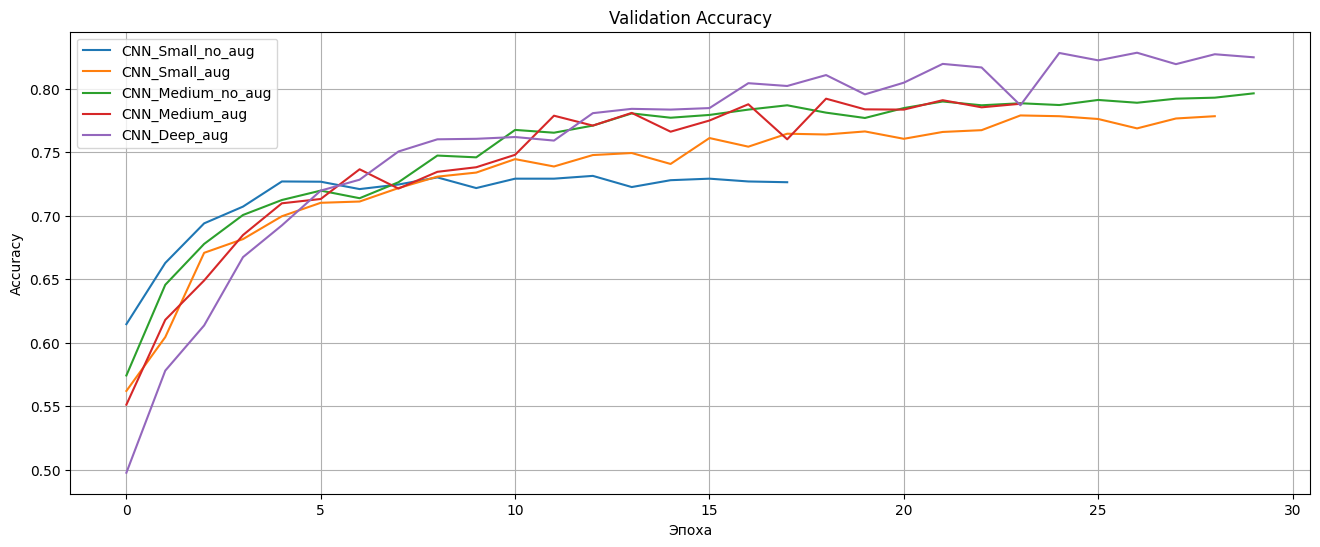

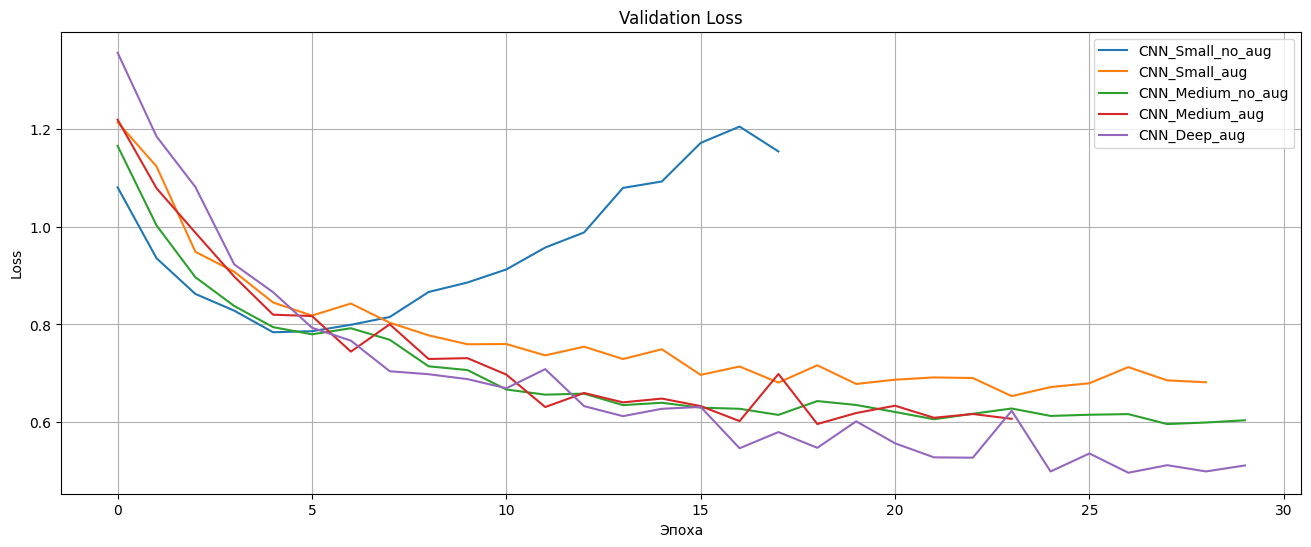

In [30]:
def plot_histories(results):
    plt.figure(figsize=(16, 6))
    for name, res in results.items():
        plt.plot(res["history"]["val_acc"], label=name)
    plt.title("Validation Accuracy")
    plt.xlabel("Эпоха")
    plt.ylabel("Accuracy")
    plt.grid(True)
    plt.legend()
    plt.show()

    plt.figure(figsize=(16, 6))
    for name, res in results.items():
        plt.plot(res["history"]["val_loss"], label=name)
    plt.title("Validation Loss")
    plt.xlabel("Эпоха")
    plt.ylabel("Loss")
    plt.grid(True)
    plt.legend()
    plt.show()


plot_histories(results)

**Вывод**:
- CNN_Small_no_aug быстро выходит на плато около 0.72–0.73
- CNN_Small_aug поднимается выше — до 0.77–0.78
- CNN_Medium_no_aug и CNN_Medium_aug сходятся около 0.79
- CNN_Deep_aug выходит на максимум около 0.83
- у CNN_Small_no_aug после нескольких эпох валидационная ошибка начинает расти и к концу уходит примерно выше 1.1
- у остальных моделей loss либо снижается, либо стабилизируется
- CNN_Deep_aug показывает самую низкую валидационную ошибку к концу обучения

In [31]:
print("\n" + "=" * 100)
print("Итоговые результаты")
print("=" * 100)

sorted_results = sorted(results.items(), key=lambda x: x[1]["test_acc"], reverse=True)
for name, res in sorted_results:
    print(
        f"{name:20s} | "
        f"Best Val Acc: {res['best_val_acc']:.4f} | "
        f"Test Acc: {res['test_acc']:.4f} | "
        f"Test Loss: {res['test_loss']:.4f}"
    )


Итоговые результаты
CNN_Deep_aug         | Best Val Acc: 0.8284 | Test Acc: 0.8202 | Test Loss: 0.5208
CNN_Medium_no_aug    | Best Val Acc: 0.7964 | Test Acc: 0.7933 | Test Loss: 0.6175
CNN_Medium_aug       | Best Val Acc: 0.7922 | Test Acc: 0.7849 | Test Loss: 0.6170
CNN_Small_aug        | Best Val Acc: 0.7790 | Test Acc: 0.7704 | Test Loss: 0.6950
CNN_Small_no_aug     | Best Val Acc: 0.7314 | Test Acc: 0.7272 | Test Loss: 1.0130


**Вывод**:
- Из всех пяти моделей лучшей оказалась CNN_Deep_aug

In [32]:
best_model_name = sorted_results[0][0]
best_result = results[best_model_name]

In [33]:
print(f"\nЛучшая модель: {best_model_name}")
print(classification_report(best_result["y_true"], best_result["y_pred"], target_names=CLASS_NAMES, digits=4))


Лучшая модель: CNN_Deep_aug
              precision    recall  f1-score   support

    airplane     0.8196    0.8860    0.8515      1000
  automobile     0.9141    0.9360    0.9249      1000
        bird     0.8194    0.6850    0.7462      1000
         cat     0.7323    0.6320    0.6785      1000
        deer     0.8128    0.7250    0.7664      1000
         dog     0.7681    0.7090    0.7374      1000
        frog     0.8034    0.8990    0.8485      1000
       horse     0.7378    0.9230    0.8201      1000
        ship     0.9089    0.8980    0.9034      1000
       truck     0.8886    0.9090    0.8987      1000

    accuracy                         0.8202     10000
   macro avg     0.8205    0.8202    0.8176     10000
weighted avg     0.8205    0.8202    0.8176     10000



**Вывод**:
- Поскольку в каждом классе по 1000 объектов, совпадение macro avg и weighted avg ожидаемо: классы сбалансированы.
- Лучше всего распознаются automobile, ship, truck, airplane, frog
- Самые трудные классы cat, bird, dog, deer

Confusion matrix

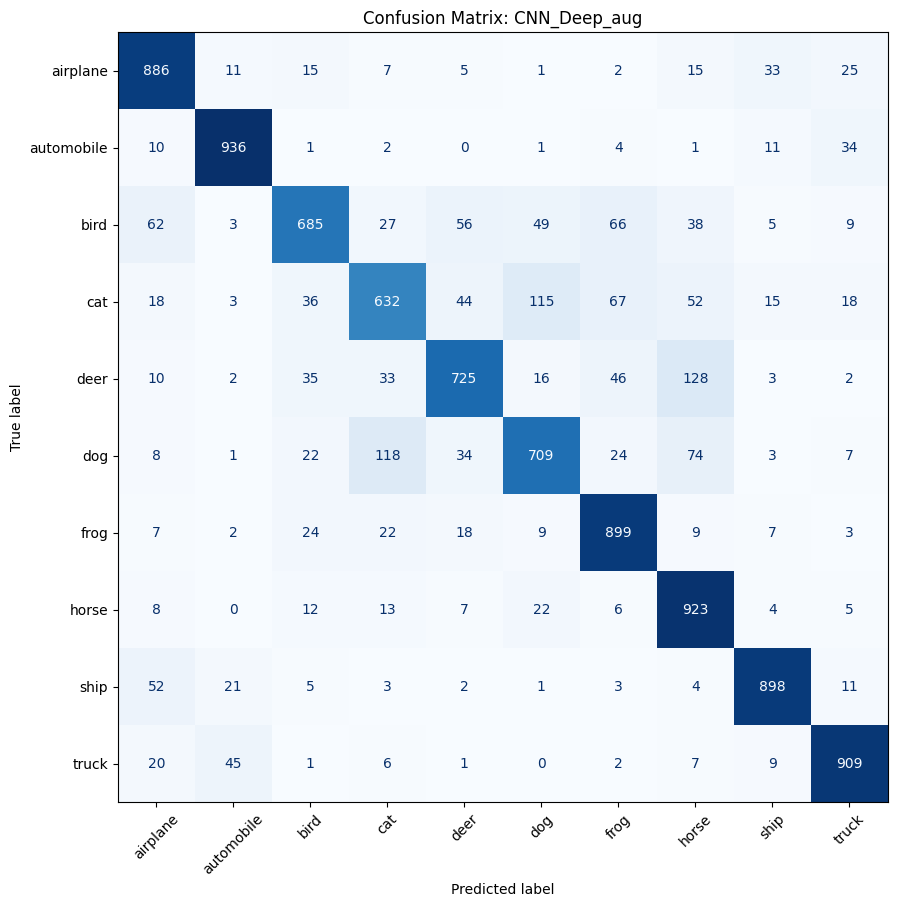

In [34]:
cm = confusion_matrix(best_result["y_true"], best_result["y_pred"])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)

fig, ax = plt.subplots(figsize=(10, 10))
disp.plot(ax=ax, cmap="Blues", xticks_rotation=45, colorbar=False)
plt.title(f"Confusion Matrix: {best_model_name}")
plt.show()

**Вывод**:
- Путаница между cat и dog, deer и horse, bird со многими путается

# Ошибочные предсказания

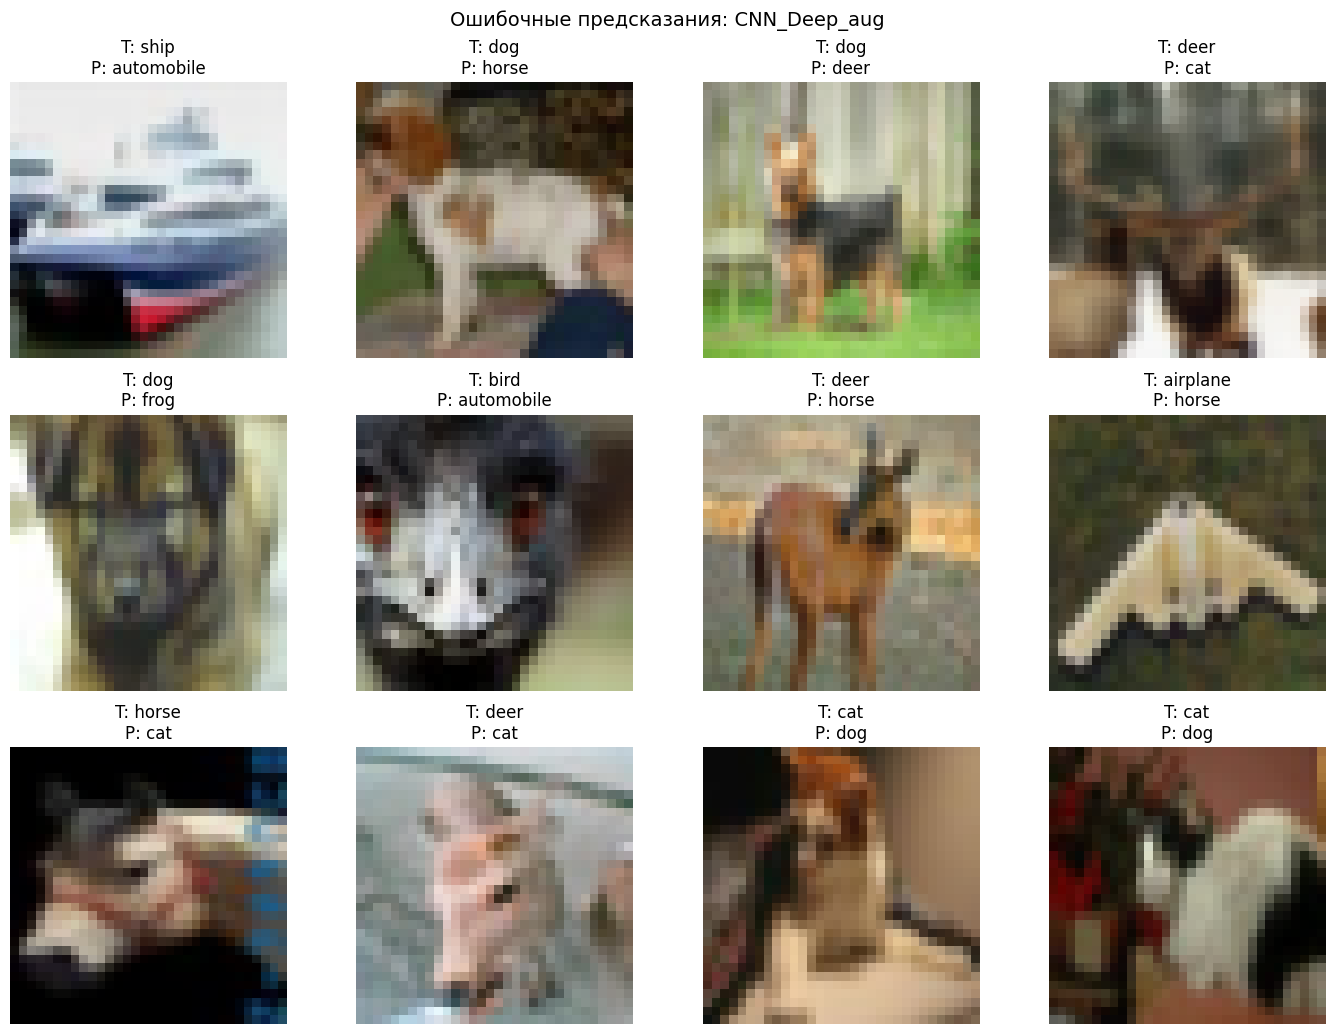

In [35]:
def show_misclassified_examples(result, class_names, max_images=12):
    y_true = result["y_true"]
    y_pred = result["y_pred"]
    images = result["test_images"]

    misclassified = []
    for img, true_lbl, pred_lbl in zip(images, y_true, y_pred):
        if true_lbl != pred_lbl:
            misclassified.append((img, true_lbl, pred_lbl))
        if len(misclassified) >= max_images:
            break

    if len(misclassified) == 0:
        print("Ошибок не найдено.")
        return

    cols = 4
    rows = int(np.ceil(len(misclassified) / cols))

    plt.figure(figsize=(14, 3.5 * rows))
    for i, (img, true_lbl, pred_lbl) in enumerate(misclassified):
        plt.subplot(rows, cols, i + 1)
        img = denormalize(img).permute(1, 2, 0).numpy()
        plt.imshow(img)
        plt.title(f"T: {class_names[true_lbl]}\nP: {class_names[pred_lbl]}")
        plt.axis("off")

    plt.suptitle(f"Ошибочные предсказания: {best_model_name}", fontsize=14)
    plt.tight_layout()
    plt.show()


show_misclassified_examples(best_result, CLASS_NAMES, max_images=12)

# Сравнение аугментации

In [36]:
def compare_augmentation(results, model_prefix):
    no_aug_name = f"{model_prefix}_no_aug"
    aug_name = f"{model_prefix}_aug"

    if no_aug_name in results and aug_name in results:
        print(f"\nСравнение аугментации для {model_prefix}:")
        print(f"{no_aug_name}: Test Acc = {results[no_aug_name]['test_acc']:.4f}")
        print(f"{aug_name}:    Test Acc = {results[aug_name]['test_acc']:.4f}")
        diff = results[aug_name]["test_acc"] - results[no_aug_name]["test_acc"]
        print(f"Разница (aug - no_aug): {diff:.4f}")

In [39]:
compare_augmentation(results, "CNN_Small")
compare_augmentation(results, "CNN_Medium")
compare_augmentation(results, "CNN_Deep")


Сравнение аугментации для CNN_Small:
CNN_Small_no_aug: Test Acc = 0.7272
CNN_Small_aug:    Test Acc = 0.7704
Разница (aug - no_aug): 0.0432

Сравнение аугментации для CNN_Medium:
CNN_Medium_no_aug: Test Acc = 0.7933
CNN_Medium_aug:    Test Acc = 0.7849
Разница (aug - no_aug): -0.0084


**Вывод**:
- Для средней сети аугментация не дала прироста
- Для маленькой сети аугментация полезна